# OpenCV: meerdere x-assen detecteren

Deze notebook detecteert **meerdere mogelijke x-assen** in chart-afbeeldingen.

De notebook kan twee soorten assen vinden:

- **horizontale x-as**: normale grafieken waarbij de x-as onderaan loopt
- **verticale x-as / gedraaide chart**: grafieken waarbij de categorie-as verticaal loopt, bijvoorbeeld bij horizontal bar charts

Belangrijk: dit is een **rule-based OpenCV pipeline**. Er wordt dus geen YOLO of deep learning gebruikt. De methode werkt vooral goed wanneer assen duidelijke donkere lijnen zijn.

## 1. Installatie

Run deze cel alleen als je packages nog niet geïnstalleerd zijn.

In [1]:
%pip install opencv-python matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


## 2. Imports en instellingen

In [4]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 8)

# Pas dit pad aan naar jouw eigen afbeelding
IMAGE_PATH = Path("../Dataset/Compliant/7.png")

# Output map
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Image path:", IMAGE_PATH)
print("Output folder:", OUTPUT_DIR)

Image path: ..\Dataset\Compliant\7.png
Output folder: ..\output


## 3. Afbeelding inladen

Image shape: (441, 605, 3)


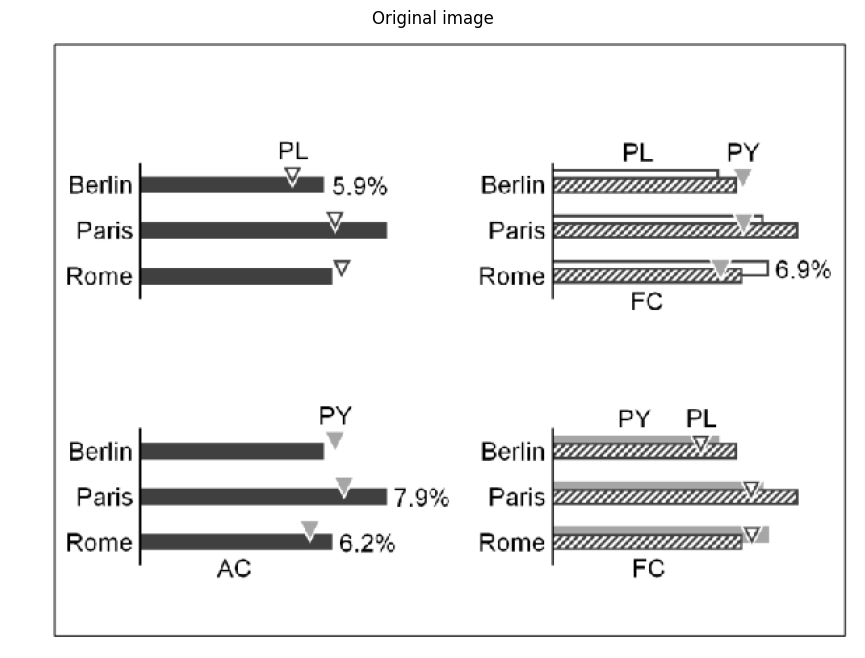

In [5]:
image = cv2.imread(str(IMAGE_PATH))

if image is None:
    raise FileNotFoundError(
        f"Image not found: {IMAGE_PATH}\n"
        "Controleer of het pad klopt en of de afbeelding bestaat."
    )

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image shape:", image.shape)

plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original image")
plt.show()

## 4. Preprocessing

We maken de afbeelding grijs en zoeken randen met Canny edge detection. Daarna maskeren we de randen van de afbeelding, omdat daar vaak borders zitten die de detectie verstoren.

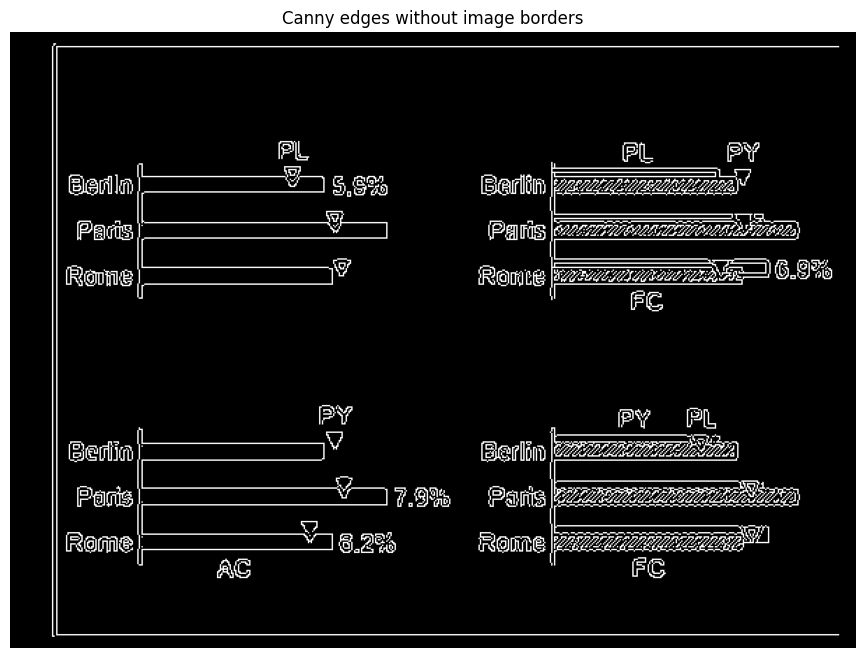

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Kleine blur om ruis te verminderen
blurred = cv2.GaussianBlur(gray, (3, 3), 0)

# Edge detection
edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

h, w = edges.shape

# Negeer buitenranden van de afbeelding
margin_x = int(w * 0.02)
margin_y = int(h * 0.02)

edges_masked = edges.copy()
edges_masked[:margin_y, :] = 0
edges_masked[h-margin_y:, :] = 0
edges_masked[:, :margin_x] = 0
edges_masked[:, w-margin_x:] = 0

plt.imshow(edges_masked, cmap="gray")
plt.axis("off")
plt.title("Canny edges without image borders")
plt.show()

## 5. Lijnen detecteren met Hough Transform

Hier zoeken we alle rechte lijnen in de afbeelding. Daarna verdelen we ze in:

- horizontale kandidaten
- verticale kandidaten

Een verticale kandidaat is handig voor charts waarbij de categorie-as aan de linkerkant staat, zoals bij horizontal bar charts.

In [7]:
def detect_lines(edges_image, min_line_length_ratio=0.08, max_line_gap=8, threshold=60):
    height, width = edges_image.shape
    min_line_length = int(min(width, height) * min_line_length_ratio)

    lines = cv2.HoughLinesP(
        edges_image,
        rho=1,
        theta=np.pi / 180,
        threshold=threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

    result = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            dx = x2 - x1
            dy = y2 - y1
            length = float(np.sqrt(dx**2 + dy**2))
            angle = float(np.degrees(np.arctan2(dy, dx)))
            result.append({
                "x1": int(x1),
                "y1": int(y1),
                "x2": int(x2),
                "y2": int(y2),
                "length": length,
                "angle": angle
            })
    return result


all_lines = detect_lines(edges_masked)

print("Total detected lines:", len(all_lines))

Total detected lines: 111


## 6. Lijnen filteren en scoren

We willen niet elke horizontale of verticale lijn. De afbeelding kan namelijk ook bevatten:

- tabelregels
- gridlines
- borders
- groene onderranden
- tekstonderstrepingen

Daarom krijgt elke lijn een score. De score gebruikt onder andere:

- lengte van de lijn
- positie in de afbeelding
- of de lijn niet precies op de afbeeldingsrand ligt
- of de lijn past bij een normale of gedraaide x-as

Voor normale verticale staafdiagrammen verwachten we vaak een **horizontale x-as lager in de plot**.  
Voor horizontal bar charts verwachten we vaak een **verticale categorie-as links in de plot**.

In [8]:
def is_near_border(line, width, height, border_ratio=0.03):
    bx = width * border_ratio
    by = height * border_ratio

    points = [(line["x1"], line["y1"]), (line["x2"], line["y2"])]
    for x, y in points:
        if x < bx or x > width - bx or y < by or y > height - by:
            return True
    return False


def line_orientation(line, angle_tolerance=10):
    angle = line["angle"]

    # Maak hoek eenvoudiger: horizontaal is rond 0 of 180, verticaal rond 90
    abs_angle = abs(angle)

    if abs_angle <= angle_tolerance or abs_angle >= 180 - angle_tolerance:
        return "horizontal"

    if abs(abs_angle - 90) <= angle_tolerance:
        return "vertical"

    return "other"


def score_horizontal_x_axis(line, width, height):
    """Score voor normale x-as: horizontale lijn, meestal lager in de chart."""
    y_avg = (line["y1"] + line["y2"]) / 2
    x_min = min(line["x1"], line["x2"])
    x_max = max(line["x1"], line["x2"])

    length_score = line["length"] / width
    lower_position_score = y_avg / height

    # Niet te dicht op onderrand, want dat is vaak border/groene rand
    border_penalty = 0
    if y_avg > height * 0.95:
        border_penalty += 2.0
    if x_min < width * 0.03 and x_max > width * 0.97:
        border_penalty += 1.5

    # Lijn moet een redelijke lengte hebben, maar niet per se volledige breedte
    score = (2.0 * length_score) + (1.0 * lower_position_score) - border_penalty
    return score


def score_vertical_x_axis(line, width, height):
    """Score voor gedraaide/category-as: verticale lijn, vaak links in de chart."""
    x_avg = (line["x1"] + line["x2"]) / 2
    y_min = min(line["y1"], line["y2"])
    y_max = max(line["y1"], line["y2"])

    length_score = line["length"] / height
    left_position_score = 1 - (x_avg / width)

    # Niet te dicht op linkerrand, want dat is vaak de afbeelding border
    border_penalty = 0
    if x_avg < width * 0.03:
        border_penalty += 2.0
    if y_min < height * 0.03 and y_max > height * 0.97:
        border_penalty += 1.5

    score = (2.0 * length_score) + (0.8 * left_position_score) - border_penalty
    return score


def get_axis_candidates(lines, image_width, image_height, min_length_ratio=0.10, top_n=10):
    horizontal = []
    vertical = []

    min_len_h = image_width * min_length_ratio
    min_len_v = image_height * min_length_ratio

    for line in lines:
        orientation = line_orientation(line)

        if orientation == "horizontal" and line["length"] >= min_len_h:
            line_copy = line.copy()
            line_copy["orientation"] = "horizontal"
            line_copy["score"] = score_horizontal_x_axis(line_copy, image_width, image_height)
            horizontal.append(line_copy)

        elif orientation == "vertical" and line["length"] >= min_len_v:
            line_copy = line.copy()
            line_copy["orientation"] = "vertical"
            line_copy["score"] = score_vertical_x_axis(line_copy, image_width, image_height)
            vertical.append(line_copy)

    horizontal = sorted(horizontal, key=lambda x: x["score"], reverse=True)[:top_n]
    vertical = sorted(vertical, key=lambda x: x["score"], reverse=True)[:top_n]

    return horizontal, vertical


horizontal_candidates, vertical_candidates = get_axis_candidates(
    all_lines,
    image_width=w,
    image_height=h,
    min_length_ratio=0.10,
    top_n=15
)

print("Horizontal axis candidates:", len(horizontal_candidates))
print("Vertical axis candidates:", len(vertical_candidates))

print("\nTop horizontal candidates:")
for i, line in enumerate(horizontal_candidates[:5], start=1):
    print(i, line)

print("\nTop vertical candidates:")
for i, line in enumerate(vertical_candidates[:5], start=1):
    print(i, line)

Horizontal axis candidates: 15
Vertical axis candidates: 4

Top horizontal candidates:
1 {'x1': 30, 'y1': 10, 'x2': 592, 'y2': 10, 'length': 562.0, 'angle': 0.0, 'orientation': 'horizontal', 'score': 1.8805269766308728}
2 {'x1': 40, 'y1': 370, 'x2': 275, 'y2': 370, 'length': 235.0, 'angle': 0.0, 'orientation': 'horizontal', 'score': 1.6158617717059274}
3 {'x1': 336, 'y1': 365, 'x2': 542, 'y2': 365, 'length': 206.0, 'angle': 0.0, 'orientation': 'horizontal', 'score': 1.5086561346301606}
4 {'x1': 336, 'y1': 364, 'x2': 542, 'y2': 364, 'length': 206.0, 'angle': 0.0, 'orientation': 'horizontal', 'score': 1.5063885609340155}
5 {'x1': 335, 'y1': 362, 'x2': 542, 'y2': 362, 'length': 207.0, 'angle': 0.0, 'orientation': 'horizontal', 'score': 1.5051591986656923}

Top vertical candidates:
1 {'x1': 30, 'y1': 432, 'x2': 30, 'y2': 11, 'length': 421.0, 'angle': -90.0, 'orientation': 'vertical', 'score': 1.1696276306665916}
2 {'x1': 33, 'y1': 430, 'x2': 33, 'y2': 11, 'length': 419.0, 'angle': -90.0, '

## 7. Meerdere x-as kandidaten tekenen

Deze cel tekent meerdere gevonden kandidaten:

- **horizontale kandidaten** worden groen getekend
- **verticale kandidaten** worden blauw getekend

Zo kun je controleren of de notebook de juiste assen vindt.

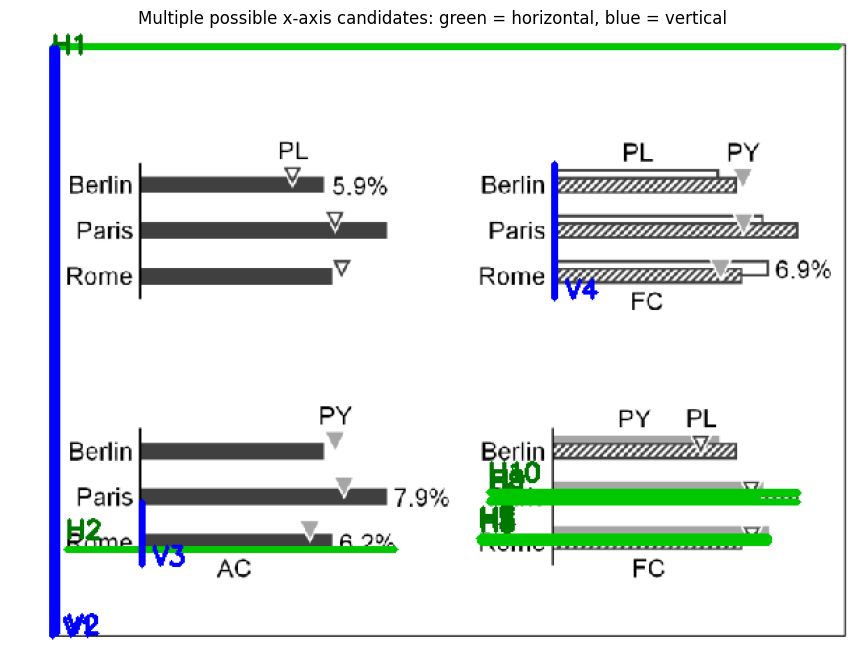

In [9]:
def draw_candidates(image_bgr, horizontal_candidates, vertical_candidates, max_horizontal=10, max_vertical=10):
    output = image_bgr.copy()

    # Horizontale kandidaten: groen
    for idx, line in enumerate(horizontal_candidates[:max_horizontal], start=1):
        x1, y1, x2, y2 = line["x1"], line["y1"], line["x2"], line["y2"]
        cv2.line(output, (x1, y1), (x2, y2), (0, 200, 0), 3)
        cv2.putText(output, f"H{idx}", (x1, max(y1 - 8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 120, 0), 2)

    # Verticale kandidaten: blauw
    for idx, line in enumerate(vertical_candidates[:max_vertical], start=1):
        x1, y1, x2, y2 = line["x1"], line["y1"], line["x2"], line["y2"]
        cv2.line(output, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(output, f"V{idx}", (min(x1 + 8, output.shape[1]-40), y1),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    return output


candidate_image = draw_candidates(
    image,
    horizontal_candidates,
    vertical_candidates,
    max_horizontal=10,
    max_vertical=10
)

plt.imshow(cv2.cvtColor(candidate_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Multiple possible x-axis candidates: green = horizontal, blue = vertical")
plt.show()

## 8. Beste kandidaten kiezen

Hier kiezen we de beste horizontale en verticale x-as kandidaat.  
Omdat jouw dataset soms meerdere charts in één afbeelding heeft, kun je ook meerdere kandidaten bewaren.

Pas `NUMBER_OF_AXES_TO_KEEP` aan als je meer of minder assen wilt tonen.

In [10]:
NUMBER_OF_AXES_TO_KEEP = 5

selected_axes = []

for line in horizontal_candidates[:NUMBER_OF_AXES_TO_KEEP]:
    selected_axes.append(line)

for line in vertical_candidates[:NUMBER_OF_AXES_TO_KEEP]:
    selected_axes.append(line)

# Sorteer op score, hoogste eerst
selected_axes = sorted(selected_axes, key=lambda x: x["score"], reverse=True)

print("Selected possible x-axes:")
for i, axis in enumerate(selected_axes, start=1):
    print(
        f"{i}. {axis['orientation']} | "
        f"score={axis['score']:.2f} | "
        f"coords=({axis['x1']}, {axis['y1']}) -> ({axis['x2']}, {axis['y2']})"
    )

Selected possible x-axes:
1. horizontal | score=1.88 | coords=(30, 10) -> (592, 10)
2. horizontal | score=1.62 | coords=(40, 370) -> (275, 370)
3. horizontal | score=1.51 | coords=(336, 365) -> (542, 365)
4. horizontal | score=1.51 | coords=(336, 364) -> (542, 364)
5. horizontal | score=1.51 | coords=(335, 362) -> (542, 362)
6. vertical | score=1.17 | coords=(30, 432) -> (30, 11)
7. vertical | score=1.16 | coords=(33, 430) -> (33, 11)
8. vertical | score=0.88 | coords=(94, 381) -> (94, 336)
9. vertical | score=0.72 | coords=(389, 190) -> (389, 94)


## 9. Eindresultaat tekenen en opslaan

Het resultaat wordt opgeslagen in de `output` map.

- groen = horizontale x-as kandidaat
- blauw = verticale / gedraaide x-as kandidaat

Saved result to: ..\output\7_multiple_x_axes_detected.png


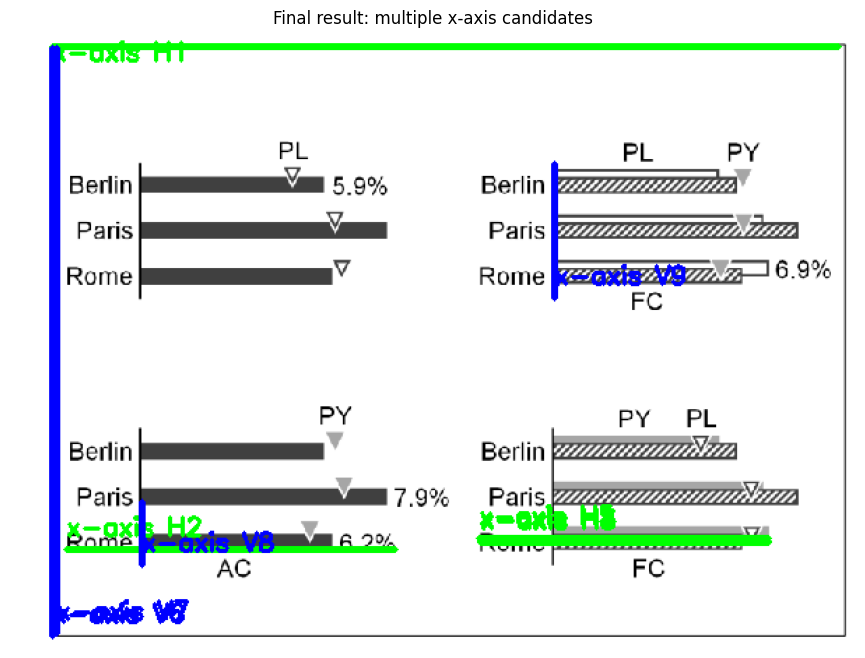

In [11]:
def draw_selected_axes(image_bgr, axes):
    output = image_bgr.copy()

    for idx, axis in enumerate(axes, start=1):
        x1, y1, x2, y2 = axis["x1"], axis["y1"], axis["x2"], axis["y2"]

        if axis["orientation"] == "horizontal":
            color = (0, 255, 0)  # green
            label = f"x-axis H{idx}"
        else:
            color = (255, 0, 0)  # blue
            label = f"x-axis V{idx}"

        cv2.line(output, (x1, y1), (x2, y2), color, 4)
        cv2.putText(output, label, (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return output


result_image = draw_selected_axes(image, selected_axes)

output_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_multiple_x_axes_detected.png"
cv2.imwrite(str(output_path), result_image)

print("Saved result to:", output_path)

plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Final result: multiple x-axis candidates")
plt.show()

## 10. Meerdere afbeeldingen automatisch testen

Deze cel test alle afbeeldingen in `Dataset/Compliant` en `Dataset/Non-Compliant`.

De output komt in:

```text
output/multiple_axis_detection/
```

Dit is handig voor je GitHub en je verslag, omdat je dan meerdere voorbeelden kunt laten zien.

In [ ]:
def detect_multiple_x_axes_for_image(image_path, output_dir, number_of_axes_to_keep=5):
    img = cv2.imread(str(image_path))
    if img is None:
        print("Could not read:", image_path)
        return None

    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred_img = cv2.GaussianBlur(gray_img, (3, 3), 0)
    edges_img = cv2.Canny(blurred_img, 50, 150)

    height, width = edges_img.shape

    # Remove image borders
    mx = int(width * 0.02)
    my = int(height * 0.02)
    edges_img[:my, :] = 0
    edges_img[height-my:, :] = 0
    edges_img[:, :mx] = 0
    edges_img[:, width-mx:] = 0

    lines = detect_lines(edges_img)
    h_candidates, v_candidates = get_axis_candidates(
        lines,
        image_width=width,
        image_height=height,
        min_length_ratio=0.10,
        top_n=15
    )

    axes = []
    axes.extend(h_candidates[:number_of_axes_to_keep])
    axes.extend(v_candidates[:number_of_axes_to_keep])
    axes = sorted(axes, key=lambda x: x["score"], reverse=True)

    result = draw_selected_axes(img, axes)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    save_path = output_dir / f"{image_path.stem}_axes.png"
    cv2.imwrite(str(save_path), result)

    return {
        "image": str(image_path),
        "output": str(save_path),
        "axes_found": len(axes),
        "horizontal_found": len(h_candidates),
        "vertical_found": len(v_candidates)
    }


dataset_folders = [
    Path("../Dataset/Compliant"),
    Path("../Dataset/Non-Compliant")
]

batch_output_dir = Path("../output/multiple_axis_detection")

image_extensions = ["*.png", "*.jpg", "*.jpeg", "*.webp"]
all_image_paths = []

for folder in dataset_folders:
    for ext in image_extensions:
        all_image_paths.extend(folder.glob(ext))

print("Images found:", len(all_image_paths))

batch_results = []
for img_path in all_image_paths:
    result = detect_multiple_x_axes_for_image(
        img_path,
        output_dir=batch_output_dir,
        number_of_axes_to_keep=5
    )
    if result is not None:
        batch_results.append(result)

print("\nBatch results:")
for item in batch_results:
    print(item)

## 11. Uitleg voor je verslag

Je kunt dit gebruiken in je documentatie:

> This notebook uses a rule-based OpenCV pipeline to detect multiple possible x-axes in chart images. The image is first converted to grayscale and processed with Canny edge detection. Then, the Hough Line Transform is used to detect straight lines. Instead of only searching for one horizontal x-axis, the pipeline separates horizontal and vertical line candidates. Horizontal candidates are useful for normal vertical bar charts, while vertical candidates are useful for rotated or horizontal bar charts where the category axis can be placed vertically. Each candidate is scored based on its length, position and distance from the image border. The highest scoring candidates are drawn on the image and saved as output.

Limitations:

> A limitation of this approach is that it remains rule-based. This means that it can still make mistakes when the chart contains many gridlines, table borders, UI elements, or multiple small charts in one image. However, compared to only selecting the lowest horizontal line, this method is more flexible because it can detect multiple axis candidates and also supports vertical axis layouts.
